In [ ]:
mahdi nasser alzaid
2240003775

# ARTI501 – Lab 3, Part 1: Task 1
## Text Analysis and NLP – IMDB Movie Reviews

**Goal:**
1. Load the IMDB Dataset of 50K Movie Reviews
2. Pre-process the text (tokenize, remove punctuation, lowercase, remove stopwords)
3. Compute: total reviews, average word count per review, number of positive reviews
   (contain "good") and negative reviews (contain "bad")
4. Create a word-frequency histogram of the most common words
5. Print the results

**Dataset:** `IMDB Dataset.csv` (Kaggle: IMDB Dataset of 50K Movie Reviews)

## 1. Import Libraries

In [1]:
import pandas as pd
import re
import string
from collections import Counter
import matplotlib.pyplot as plt

import nltk
from nltk.corpus import stopwords
# nltk.download('stopwords')   # uncomment on first run


## 2. Load the Dataset

In [2]:
df = pd.read_csv('IMDB Dataset.csv')
print('Shape:', df.shape)
df.head()


Shape: (50000, 2)


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


## 3. Pre-process the Text

- Strip leftover HTML tags (the raw reviews contain `<br />` line breaks)
- Lowercase
- Remove punctuation
- Tokenize (simple whitespace split, after punctuation removal)
- Remove English stopwords, keep only alphabetic tokens

In [3]:
stop_words = set(stopwords.words('english'))
punct_table = str.maketrans('', '', string.punctuation)

def preprocess(text):
    text = re.sub(r'<.*?>', ' ', text)        # remove HTML tags e.g. <br />
    text = text.lower()
    text = text.translate(punct_table)         # remove punctuation
    tokens = text.split()                      # tokenize
    tokens = [w for w in tokens if w.isalpha() and w not in stop_words]
    return tokens

df['tokens'] = df['review'].apply(preprocess)
df['word_count'] = df['tokens'].apply(len)
df[['review', 'tokens', 'word_count']].head()


,review,tokens,word_count
0,One of the other reviewers has mentioned that ...,"[one, reviewers, mentioned, watching, oz, epis...",166
1,A wonderful little production. <br /><br />The...,"[wonderful, little, production, filming, techn...",84
2,I thought this was a wonderful way to spend ti...,"[thought, wonderful, way, spend, time, hot, su...",85
3,Basically there's a family where a little boy ...,"[basically, theres, family, little, boy, jake,...",67
4,"Petter Mattei's ""Love in the Time of Money"" is...","[petter, matteis, love, time, money, visually,...",125


## 4. Calculate Statistics

In [4]:
total_reviews = len(df)
avg_word_count = df['word_count'].mean()

# Positive: review text contains the word "good" (as a whole word)
# Negative: review text contains the word "bad" (as a whole word)
positive_reviews = df['review'].str.lower().str.contains(r'\bgood\b', regex=True).sum()
negative_reviews = df['review'].str.lower().str.contains(r'\bbad\b', regex=True).sum()

print(f'Total number of reviews:              {total_reviews}')
print(f'Average word count per review:        {avg_word_count:.2f}')
print(f'Reviews containing "good":             {positive_reviews}')
print(f'Reviews containing "bad":              {negative_reviews}')


Total number of reviews:              50000
Average word count per review:        118.81
Reviews containing "good":             19004
Reviews containing "bad":              11788


## 5. Word Frequency Histogram

In [5]:
all_words = [w for tokens in df['tokens'] for w in tokens]
word_freq = Counter(all_words)
top20 = word_freq.most_common(20)

top20_df = pd.DataFrame(top20, columns=['Word', 'Count'])
top20_df


,Word,Count
0,movie,85222
1,film,76028
2,one,51476
3,like,39063
4,good,28912
5,even,24582
6,would,24036
7,time,23959
8,really,23011
9,see,22640


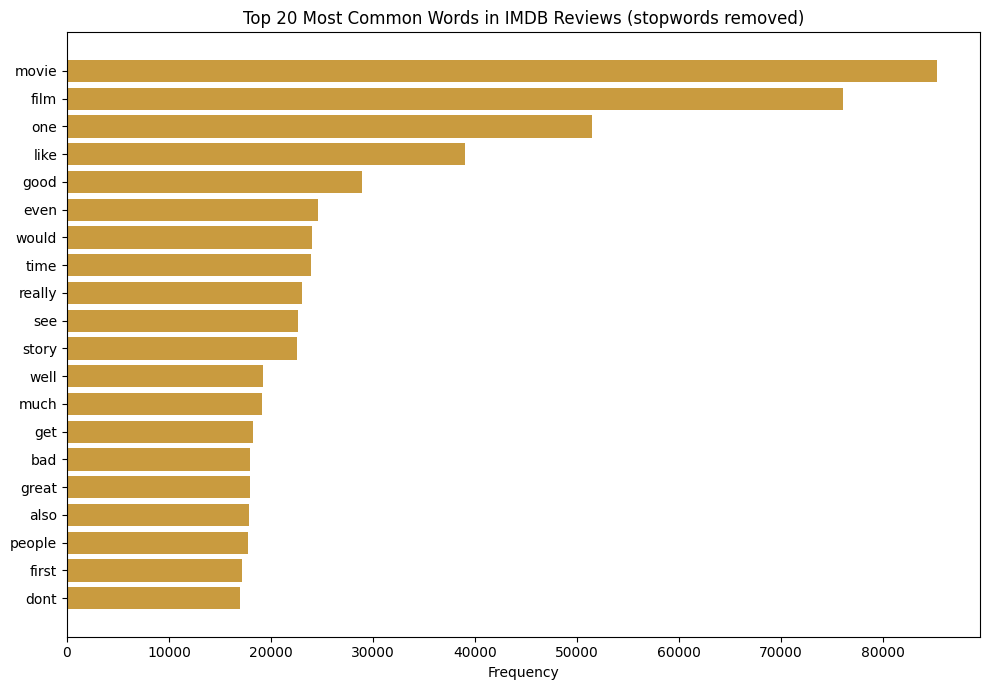

In [6]:
plt.figure(figsize=(10, 7))
plt.barh(top20_df['Word'][::-1], top20_df['Count'][::-1], color='#c99b3f')
plt.xlabel('Frequency')
plt.title('Top 20 Most Common Words in IMDB Reviews (stopwords removed)')
plt.tight_layout()
plt.savefig('imdb_word_frequency.png', dpi=150)
plt.show()


## 6. Print Results Summary

In [7]:
print('=== IMDB Reviews Analysis Summary ===')
print(f'Total reviews analyzed:         {total_reviews}')
print(f'Average word count per review:  {avg_word_count:.2f}')
print(f'Reviews containing "good":       {positive_reviews} ({positive_reviews/total_reviews:.1%})')
print(f'Reviews containing "bad":        {negative_reviews} ({negative_reviews/total_reviews:.1%})')
print()
print('Top 10 most common words:')
for word, count in top20[:10]:
    print(f'  {word}: {count}')


=== IMDB Reviews Analysis Summary ===
Total reviews analyzed:         50000
Average word count per review:  118.81
Reviews containing "good":       19004 (38.0%)
Reviews containing "bad":        11788 (23.6%)

Top 10 most common words:
  movie: 85222
  film: 76028
  one: 51476
  like: 39063
  good: 28912
  even: 24582
  would: 24036
  time: 23959
  really: 23011
  see: 22640
